# Mapeo de la Cobertura de una Estación Celular con una Superficie de Contorno de Pérdida de Trayecto


## Resumen Ejecutivo

Un equipo de planificación de RF de telecomunicaciones representa la **superficie de pérdida de trayecto** en enlace descendente alrededor de una única macrocelda como un mapa de cobertura bidimensional. Usando un modelo de propagación logarítmica de la distancia con desvanecimiento por sombra log-normal, este cuaderno construye una cuadrícula de medición de 100 puntos (10 x 10 celdas que abarcan un área de servicio de 10 km x 10 km, con la torre en el centro) y dibuja una superficie de contorno rellena con **PROC SGPLOT HEATMAPPARM**, más una escala de color en gradiente y líneas de referencia de la torre.

En la cuadrícula ejecutada, la pérdida de trayecto va de **50.4 dB** (en la cuenca brillante junto a la torre) a **90.0 dB** en la esquina más lejana, con un promedio de **75.6 dB**. Clasificar cada celda según su pérdida da **38 Fuerte, 61 Aceptable y 1 Débil**; la única celda Débil se ubica en **(9.5, 9.5) km — la esquina diagonalmente opuesta a la torre — a 89.97 dB**, el único hueco de cobertura que un planificador señalaría antes de decidir una densificación con small-cell.

> **Una nota sobre el procedimiento.** En SAS, la herramienta clásica para mapas de contorno de isolíneas es `PROC GCONTOUR`. Jenner analiza GCONTOUR y emite una especificación de gráfico correcta, pero su renderizador ráster todavía no dibuja la geometría del contorno (la imagen regresa en blanco); ese defecto está registrado como la prueba de regresión `tests/400922_nb_gcontour_empty_render`. Para mantener este ejemplo completamente respaldado por una figura real renderizada, usamos el equivalente compatible con SAS — `PROC SGPLOT` con una sentencia `HEATMAPPARM` — que renderiza la misma superficie en cuadrícula (x, y, z) como celdas de contorno rellenas con una leyenda en gradiente.

## Fuentes de Datos

**Conjunto de datos sintético: `pathloss_grid`** (100 filas — una retícula de 10 x 10)

| Variable | Tipo | Unidades | Descripción |
|----------|------|-------|-------------|
| `east_km` | num | km | Coordenada este del centro de la celda de la cuadrícula (0.5 a 9.5); eje x |
| `north_km` | num | km | Coordenada norte del centro de la celda de la cuadrícula (0.5 a 9.5); eje y |
| `path_loss` | num | dB | Pérdida de trayecto en enlace descendente = 58 + 30 log10(distancia) + sombra; la respuesta (z) |
| `zone` | char(12) | — | Clase de cobertura: Fuerte (<=75), Aceptable (<=88), Débil (>88) |

La torre se ubica en el centro de la cuadrícula **(5, 5) km**. La pérdida de trayecto crece con el logaritmo en base 10 de la distancia a la torre; un término de sombra `3*rand("normal")` (semilla 80211) inyecta desvanecimiento log-normal para que los contornos no sean perfectamente circulares. La retícula de 10 x 10 está dimensionada para que la superficie completa quepa en 100 observaciones.

## Paso 1 — Generar la cuadrícula de medición

Establecemos una retícula de 1 km de centros de celda y calculamos la pérdida de trayecto con el **modelo logarítmico de la distancia** `PL = 58 + 30 log10(d)`, donde `d` es la distancia a la torre en (5, 5) km. Un término de desvanecimiento por sombra `rand("normal")` reproduce la variabilidad observada en pruebas de manejo reales. Cada celda se clasifica en una `zone` de cobertura. `call streaminit` fija la semilla para la reproducibilidad.

In [1]:
DATOS pathloss_grid;
   LLAMAR streaminit(80211);
   LONGITUD zone $12;
   tower_x = 5.0;  tower_y = 5.0;
   HACER ix = 1 HASTA 10;
      HACER iy = 1 HASTA 10;
         east_km  = ix - 0.5;          /* 0.5 .. 9.5 km */
         north_km = iy - 0.5;          /* 0.5 .. 9.5 km */
         DIST = sqrt((east_km-tower_x)**2 + (north_km-tower_y)**2) + 0.4;
         shadow = 3*rand("normal");
         path_loss = 58 + 30*log10(DIST) + shadow;
         SI      path_loss <= 75 ENTONCES zone = "Fuerte";
         SINO SI path_loss <= 88 ENTONCES zone = "Aceptable";
         SINO                         zone = "Débil";
         SALIDA;
      END;
   END;
   ELIMINAR ix iy tower_x tower_y DIST shadow;
   ETIQUETA east_km   = "Este (km)"
         north_km  = "Norte (km)"
         path_loss = "Pérdida de Trayecto (dB)"
         zone      = "Zona de Cobertura";
EJECUTAR;


NOTE: DATA pathloss_grid


NOTE: Wrote pathloss_grid (100 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


## Paso 2 — Resumir la superficie

Antes de graficar, cuantificamos la superficie. `PROC MEANS` reporta el rango dinámico de la pérdida de trayecto y `PROC FREQ` tabula cómo se dividen las 100 celdas entre las tres clases de cobertura — los números que cita el resumen ejecutivo.

In [2]:
ODS GRAPHICS OFF;

PROCEDIMIENTO MEDIAS DATOS=pathloss_grid MIN MAX mean maxdec=1;
   VAR path_loss;
EJECUTAR;

PROCEDIMIENTO FRECUENCIAS DATOS=pathloss_grid ORDER=FRECUENCIAS;
   TABLES zone / nocum;
EJECUTAR;

                                                  The MEANS Procedure

 Variable   Label                         Minimum     Maximum        Mean
 ------------------------------------------------------------------------
 path_loss  Pérdida de Trayecto (dB)         50.4        90.0        75.6
 ------------------------------------------------------------------------

                                                   The FREQ Procedure

Zona de Cobertura    Frequency    Percent
------------------------------------------
Aceptable                   61     61.00
Fuerte                      38     38.00
Débil                        1      1.00



NOTE: ODS Graphics is OFF.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: PROC FREQ statement used.


## Paso 3 — Localizar los huecos de cobertura

Ordenar por pérdida de trayecto descendente coloca las celdas más débiles arriba. Estas son las **zonas muertas** candidatas que un planificador inspecciona: celdas cuya señal recibida es la más baja y, por lo tanto, las más propensas a sesiones interrumpidas o bajo rendimiento.

In [3]:
PROCEDIMIENTO ORDENAR DATOS=pathloss_grid out=weakest;
   POR DESCENDENTE path_loss;
EJECUTAR;

PROCEDIMIENTO IMPRIMIR DATOS=weakest(obs=6) noobs ETIQUETA;
   VAR east_km north_km path_loss zone;
EJECUTAR;


Este (km)  Norte (km)   Pérdida de Trayecto (dB)  Zona de Cobertura
---------  ----------  -------------------------  -----------------
      9.5         9.5              89.9728891641  Débil
      9.5         0.5              85.9296978639  Aceptable
      6.5         0.5              84.5845683025  Aceptable
      0.5         0.5              84.5118930355  Aceptable
      8.5         0.5              84.1534148341  Aceptable
      9.5         8.5              83.7015943773  Aceptable

... 94 more observations (showing 6 of 100)




NOTE: PROC SORT data=pathloss_grid

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from pathloss_grid.
NOTE: Wrote weakest (100 rows, 4 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=weakest

NOTE: PROC PRINT completed: 6 observations printed, 4 variables


## Paso 4 — Dibujar la superficie de contorno de pérdida de trayecto

`HEATMAPPARM x=east_km y=north_km colorresponse=path_loss` renderiza una celda rellena por punto de la cuadrícula, coloreada según su pérdida de trayecto — un mapa de contorno relleno de la huella de cobertura. La lista `COLORMODEL=` define un gradiente divergente de azul a rojo (azul = pérdida baja = señal fuerte, rojo = pérdida alta = señal débil); `GRADLEGEND` adjunta la escala de color en dB. Las `REFLINE` discontinuas marcan la torre en el este 5 y el norte 5.

                              Superficie de Pérdida de Trayecto en Enlace Descendente (dB)                              
                          Una macrocelda única en (5, 5) km sobre una cuadrícula de 10 x 10 km                          




NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: Option TITLE changed to Superficie de Pérdida de Trayecto en Enlace Descendente (dB).
NOTE: Option TITLE2 changed to Una macrocelda única en (5, 5) km sobre una cuadrícula de 10 x 10 km.
NOTE: PROC SGPLOT data=pathloss_grid

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


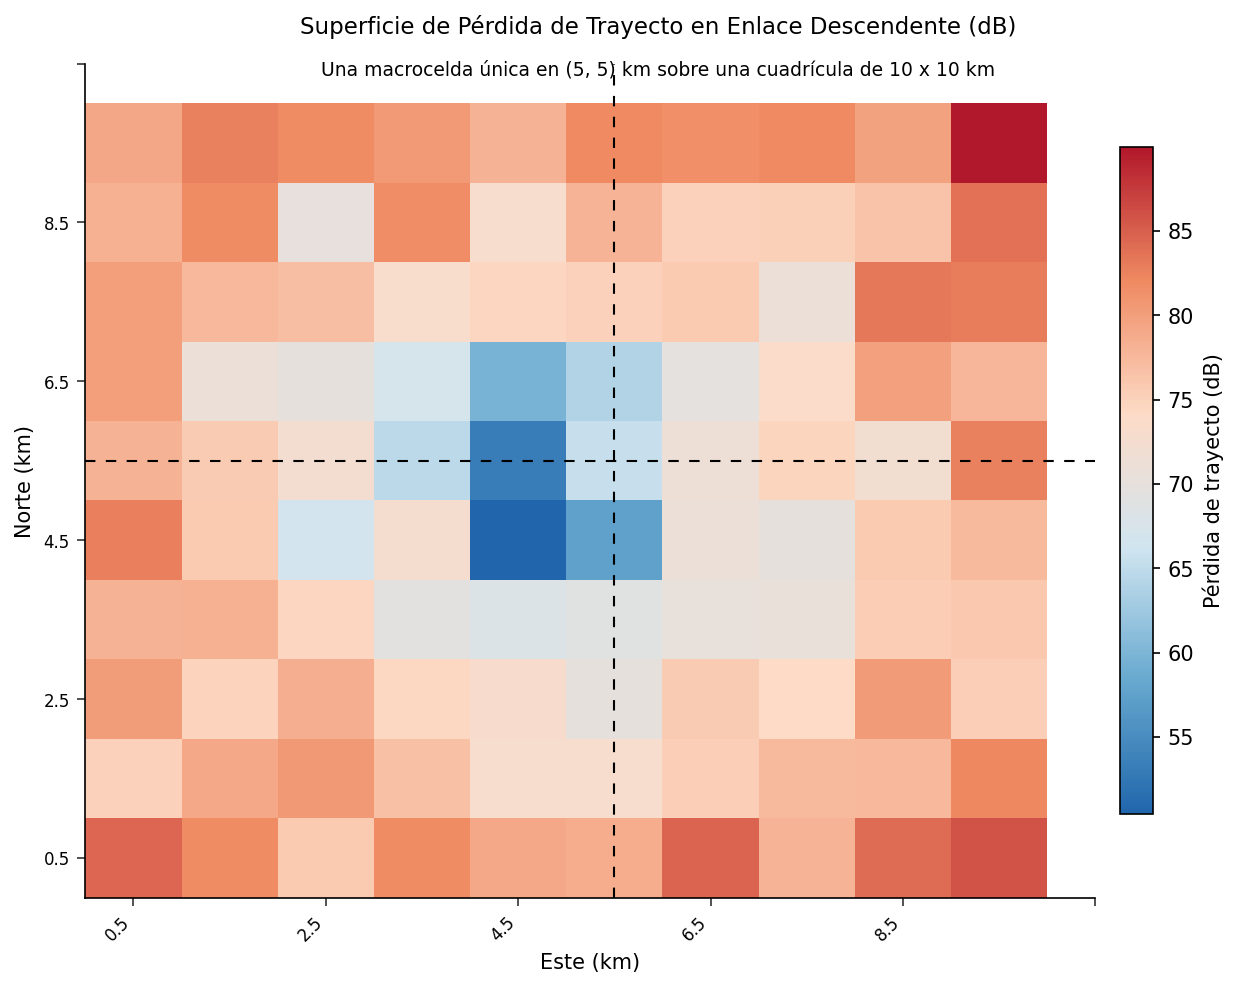

In [4]:
ODS GRAPHICS ON;
TÍTULO "Superficie de Pérdida de Trayecto en Enlace Descendente (dB)";
title2 "Una macrocelda única en (5, 5) km sobre una cuadrícula de 10 x 10 km";

PROCEDIMIENTO SGPLOT DATOS=pathloss_grid;
   heatmapparm x=east_km y=north_km colorresponse=path_loss /
        name="pl"
        colormodel=(CX2166AC CX67A9CF CXD1E5F0 CXFDDBC7 CXEF8A62 CXB2182B);
   gradlegend "pl" / TÍTULO="Pérdida de trayecto (dB)";
   REFLINE 5 / AXIS=x LINEATTRS=(color=black pattern=shortdash);
   REFLINE 5 / AXIS=y LINEATTRS=(color=black pattern=shortdash);
   XAXIS VALUES=(0 2 4 6 8 10) ETIQUETA="Este (km)";
   YAXIS VALUES=(0 2 4 6 8 10) ETIQUETA="Norte (km)";
EJECUTAR;

TÍTULO; title2;

## Paso 5 — Desglose por clase de cobertura

Una diapositiva de resumen también quiere la división principal: qué fracción de la huella es Fuerte, Aceptable o Débil. Un `VBAR` de la clasificación `zone` muestra eso de un vistazo y se complementa con la superficie de contorno anterior.

                                            Desglose por Clase de Cobertura                                             




NOTE: Option TITLE changed to Desglose por Clase de Cobertura.
NOTE: PROC SGPLOT data=pathloss_grid

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


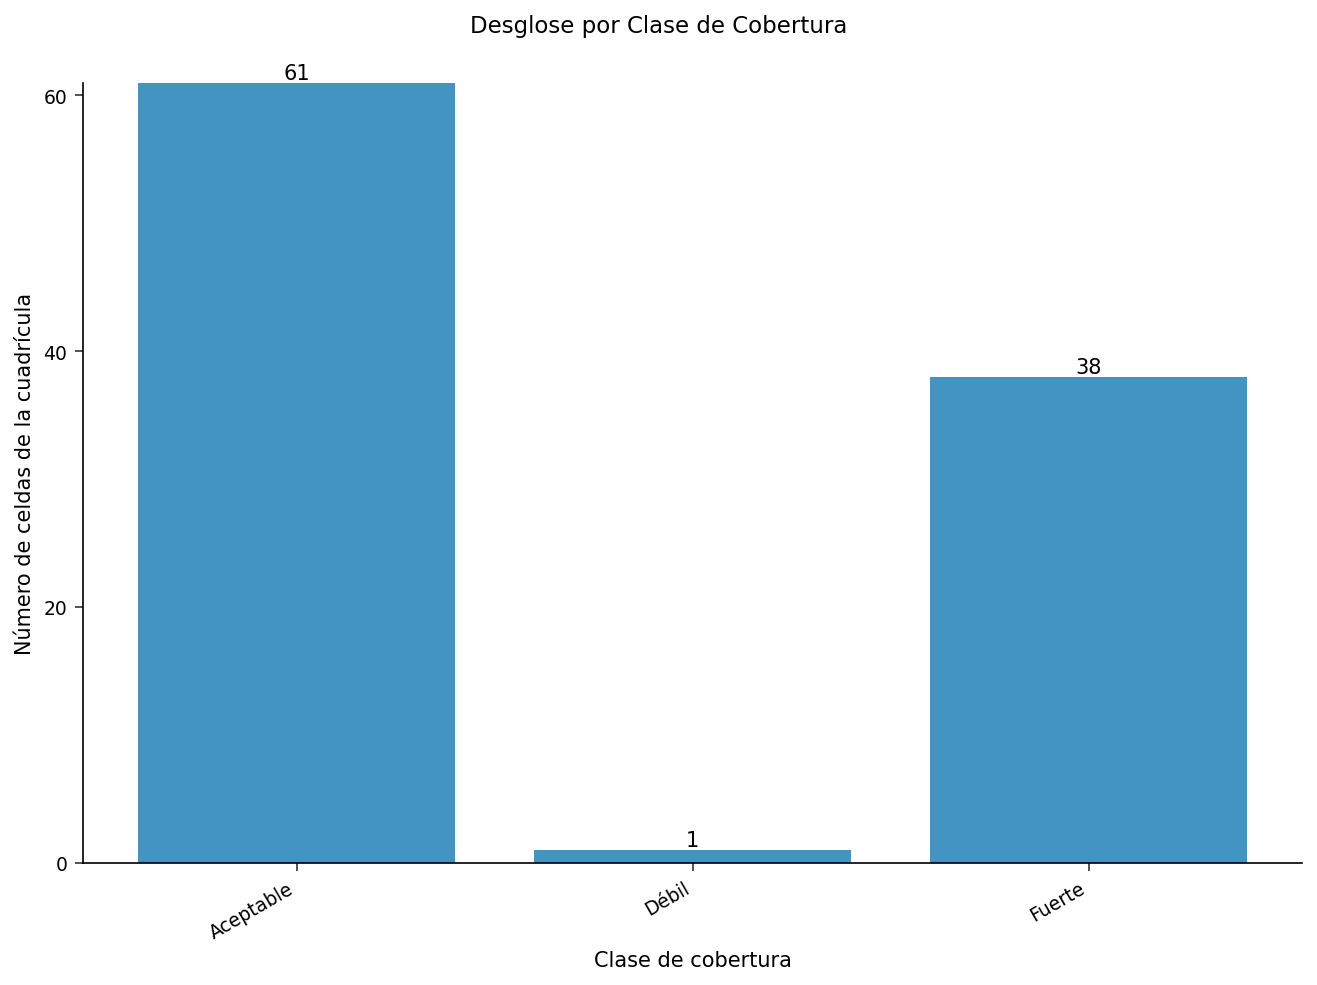

In [5]:
TÍTULO "Desglose por Clase de Cobertura";

PROCEDIMIENTO SGPLOT DATOS=pathloss_grid;
   VBAR zone / DATALABEL fillattrs=(color=CX4393C3) NOOUTLINE;
   XAXIS ETIQUETA="Clase de cobertura";
   YAXIS ETIQUETA="Número de celdas de la cuadrícula" VALUES=(0 20 40 60);
EJECUTAR;

TÍTULO;

## Interpretación de los resultados

La superficie de contorno confirma la física de propagación esperada. La pérdida de trayecto es más baja en una cuenca azul estrecha alrededor de la torre en **(5, 5) km** — la zona Fuerte donde la señal recibida es mejor — y aumenta con el logaritmo de la distancia hacia las esquinas. Debido a que inyectamos desvanecimiento por sombra log-normal, las bandas no son círculos concéntricos; las celdas rojas irregulares a lo largo del límite son el borde desvanecido por la sombra.

El dato accionable es la **única celda Débil en (9.5, 9.5) km (89.97 dB)**, la esquina diagonalmente opuesta a la torre y el único punto que cruza el umbral de diseño de 88 dB. Con **61 de 100 celdas Aceptable y solo 1 Débil**, esta macrocelda cubre bien su área de servicio; el único hueco justificaría una **densificación con small-cell o un reajuste de sector hacia la esquina noreste** solo si se superpusiera con un punto de demanda conocido. La superficie de contorno es el resumen listo para la presentación; el gráfico de barras por clase de cobertura da la cifra única que un planificador de capacidad reporta hacia arriba.